# Runtime palette and figure checks

This tutorial checks palettes that exist at runtime and colours extracted from Python figures created with various plotting backends. For source-code and notebook scanning, use the [static linter](../static-linter); for command-line and pre-commit workflows, see [CLI, configuration, and CI](../cli-configuration).

In [2]:
from cvdlint import check_figure, palette_check

## Check an explicit palette

`palette_check()` returns structured data instead of printing a terminal report. Compare a confusable palette with an accessible one before inspecting the failure in detail.

In [3]:
confusable = ["#E41A1C", "#4DAF4A", "#377EB8"]
accessible = ["#440154", "#21918C", "#FDE725"]
confusable_result = palette_check(confusable)
accessible_result = palette_check(accessible)
{
    "confusable_pass": confusable_result.passed,
    "accessible_pass": accessible_result.passed,
}

{'confusable_pass': False, 'accessible_pass': True}

In [4]:
for problem in confusable_result.problems:
    print(
        f"{problem.condition}: {problem.first_color} / "
        f"{problem.second_color} = {problem.distance:.2f} "
        f"< {problem.tolerance:.2f}"
    )

deuteranopia: #E41A1C / #4DAF4A = 9.60 < 10.00


Use `raise_for_failure()` in tests or pipelines. Here the exception is caught so the tutorial can continue.

In [5]:
try:
    confusable_result.raise_for_failure()
except AssertionError as error:
    print(error)

Palette is not CVD-safe:
  deuteranopia: #E41A1C / #4DAF4A = 9.60 < 10.00


## Adjust the policy

The Python API and CLI both default to an absolute CIEDE2000 tolerance of `10`. Tolerance, simulation severity, and metric can be changed explicitly.

In [6]:
stricter = palette_check(accessible, tolerance=15, severity=0.8)
stricter.passed

True

## Inspect a figure

`cvdlint` provides adapters that inspect colours stored on completed plotting objects. `check_figure()` infers Matplotlib and Plotly from supported native figure classes and their subclasses, and PyROOT from ROOT's runtime type information; unrecognised objects raise `TypeError`. Pass the underlying figure rather than an axes, grid, or custom wrapper—for example, `check_figure(ax.figure)` or `check_figure(grid.fig)`. Optional plotting libraries are imported only after their object type is detected.

### Check a Matplotlib figure

This example uses Matplotlib's `Set1` colormap rather than passing a palette to cvdlint.

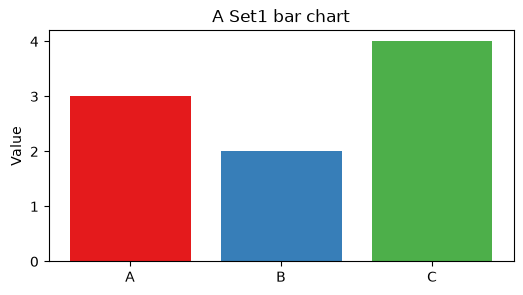

In [7]:
import matplotlib.pyplot as plt
from IPython.display import HTML, display

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(
    ["A", "B", "C"],
    [3, 2, 4],
    color=plt.colormaps["Set1"].colors[:3],
)
ax.set(title="A Set1 bar chart", ylabel="Value")
display(fig)
plt.close(fig)

In [8]:
figure_result = check_figure(fig)
try:
    figure_result.raise_for_failure()
except AssertionError as error:
    print(error)

Palette is not CVD-safe:
  deuteranopia: #E41A1C / #4DAF4A = 9.60 < 10.00


Replace `Set1` with three colours sampled from `viridis` (known for being cvd-friendly), then check the resulting figure again.

True


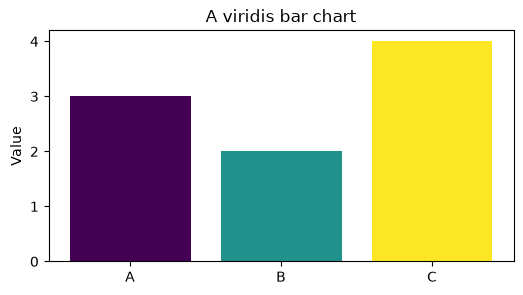

In [14]:
viridis = [plt.colormaps["viridis"](x) for x in (0.0, 0.5, 1.0)]
safe_fig, safe_ax = plt.subplots(figsize=(6, 3))
safe_ax.bar(["A", "B", "C"], [3, 2, 4], color=viridis)
safe_ax.set(title="A viridis bar chart", ylabel="Value")
print(check_figure(safe_fig).passed)
display(safe_fig)
plt.close(safe_fig)

### Check a Seaborn figure

Seaborn creates Matplotlib figures, so it uses the same adapter under the hood. Here Seaborn selects and renders the named `Set1` palette. `cvdlint` checks the final colours used in the plot, which are desaturated by Seaborn's default `saturation=0.75`, rather than the original `Set1` values.

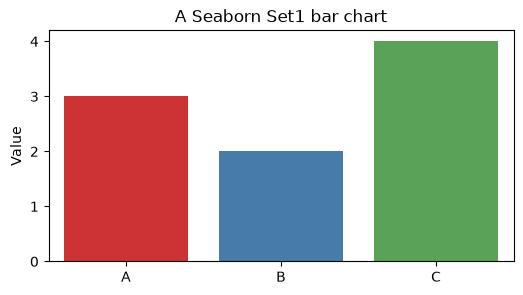

deuteranopia: #CB3335 / #59A257 = 9.50


In [17]:
import seaborn as sns

seaborn_fig, seaborn_ax = plt.subplots(figsize=(6, 3))
sns.barplot(
    x=["A", "B", "C"],
    y=[3, 2, 4],
    hue=["A", "B", "C"],
    palette="Set1",
    ax=seaborn_ax,
)
seaborn_ax.set(title="A Seaborn Set1 bar chart", ylabel="Value")
display(seaborn_fig)
plt.close(seaborn_fig)
seaborn_result = check_figure(seaborn_fig)
for problem in seaborn_result.problems:
    print(
        f"{problem.condition}: {problem.first_color} / "
        f"{problem.second_color} = {problem.distance:.2f}"
    )

### Check a Plotly figure

The Plotly adapter checks hexadecimal colours explicitly assigned to traces. It does not report unused colours expanded from a Plotly template.

In [11]:
import plotly.graph_objects as go

plotly_fig = go.Figure(
    go.Bar(
        x=["A", "B", "C"],
        y=[3, 2, 4],
        marker_color=["#E41A1C", "#377EB8", "#4DAF4A"],
    )
)
plotly_fig.update_layout(title="A Plotly Set1 bar chart")
plotly_result = check_figure(plotly_fig)
for problem in plotly_result.problems:
    print(
        f"{problem.condition}: {problem.first_color} / "
        f"{problem.second_color} = {problem.distance:.2f}"
    )
display(HTML(plotly_fig.to_html(full_html=False, include_plotlyjs="cdn")))

deuteranopia: #E41A1C / #4DAF4A = 9.60


### Check a PyROOT canvas

PyROOT users can also check their canvas for confusable palettes by using pyROOT and the cvdlint adapter. It checks (one-liner of how adapter works)
NOTE: PyROOT is distributed by the ROOT project rather than installed by a cvdlint extra.

In [15]:
import uuid

import ROOT

ROOT.gStyle.SetOptStat(0)
run_id = uuid.uuid4().hex
canvas = ROOT.TCanvas(f"cvdlint_canvas_{run_id}", "Set1 bars", 600, 400)
categories = ["A", "B", "C"]
values = [3, 2, 4]
colours = ["#E41A1C", "#377EB8", "#4DAF4A"]
histograms = []
for index, (value, colour) in enumerate(zip(values, colours, strict=True)):
    histogram = ROOT.TH1F(
        f"cvdlint_h{index}_{run_id}",
        "Set1 bar chart;Category;Value",
        3,
        0,
        3,
    )
    for bin_index, category in enumerate(categories, start=1):
        histogram.GetXaxis().SetBinLabel(bin_index, category)
    histogram.SetBinContent(index + 1, value)
    root_colour = ROOT.TColor.GetColor(colour)
    histogram.SetFillColor(root_colour)
    histogram.SetLineColor(root_colour)
    histogram.SetBarWidth(0.8)
    histogram.SetBarOffset(0.1)
    histogram.SetMinimum(0)
    histogram.SetMaximum(5)
    histogram.Draw("BAR SAME" if index else "BAR")
    histograms.append(histogram)
canvas.Update()
root_result = check_figure(canvas)
for problem in root_result.problems:
    print(
        f"{problem.condition}: {problem.first_color} / "
        f"{problem.second_color} = {problem.distance:.2f}"
    )
display(canvas)

deuteranopia: #E41A1C / #4DAF4A = 9.60
